In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('sales_data_sample.csv', encoding='latin-1')
print('Dataset loaded successfully')
print('Shape:', df.shape)

Dataset loaded successfully
Shape: (2823, 25)


In [4]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [6]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [7]:
# check for null values
print('Null values in each column:')
print(df.isnull().sum())

Null values in each column:
ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64


In [8]:
# remove null values
df = df.dropna()

# remove duplicates
df = df.drop_duplicates()

# convert date column to datetime
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

print('Data cleaned!')
print('New shape:', df.shape)

Data cleaned!
New shape: (147, 25)


In [9]:
total_sales = df['SALES'].sum()
avg_sales = df['SALES'].mean()
max_sale = df['SALES'].max()
min_sale = df['SALES'].min()

print('Total Sales:', round(total_sales, 2))
print('Average Sales:', round(avg_sales, 2))
print('Maximum Sale:', round(max_sale, 2))
print('Minimum Sale:', round(min_sale, 2))

Total Sales: 506562.52
Average Sales: 3446.0
Maximum Sale: 9774.03
Minimum Sale: 652.35


In [10]:
# category wise sales
category_sales = df.groupby('PRODUCTLINE')['SALES'].sum()
print('Category-wise Sales:')
print(category_sales)

Category-wise Sales:
PRODUCTLINE
Classic Cars        161870.46
Motorcycles          75476.67
Planes               63772.09
Ships                 1089.36
Trucks and Buses     66020.96
Vintage Cars        138332.98
Name: SALES, dtype: float64


In [11]:
# country wise sales
country_sales = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)
print('Country-wise Sales:')
print(country_sales)

Country-wise Sales:
COUNTRY
Australia    506562.52
Name: SALES, dtype: float64


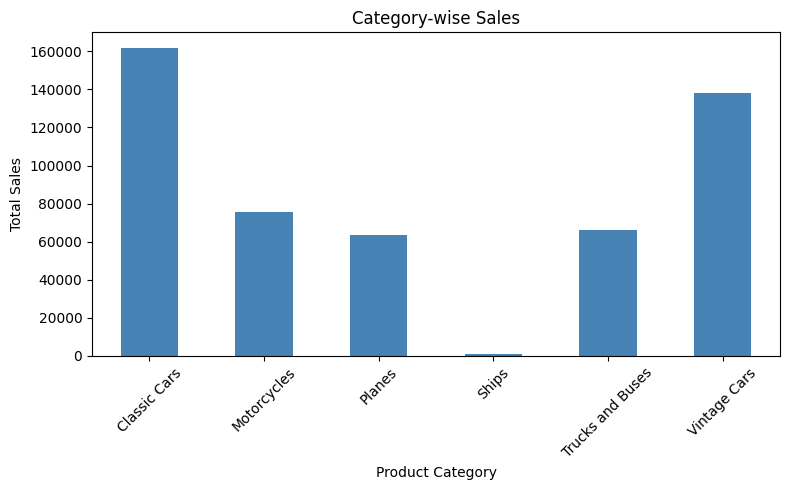

In [13]:
# bar chart - category wise sales
category_sales = df.groupby('PRODUCTLINE')['SALES'].sum()

plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', color='steelblue')
plt.title('Category-wise Sales')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

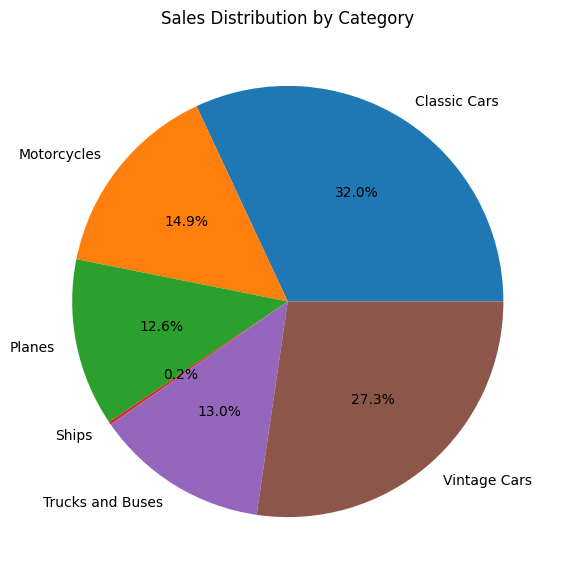

In [14]:
# pie chart - category sales distribution
plt.figure(figsize=(7, 7))
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Distribution by Category')
plt.ylabel('')
plt.show()

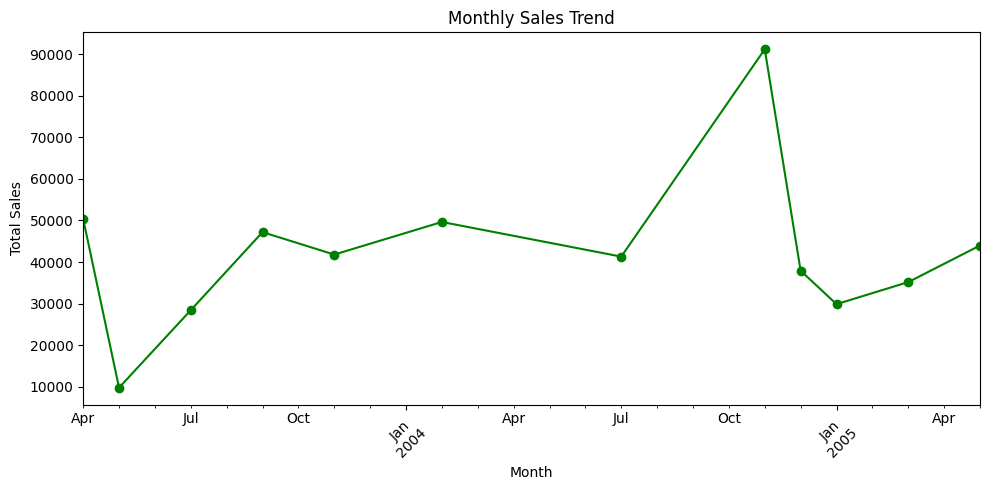

In [15]:
# monthly sales trend
df['MONTH'] = df['ORDERDATE'].dt.to_period('M')
monthly_sales = df.groupby('MONTH')['SALES'].sum()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

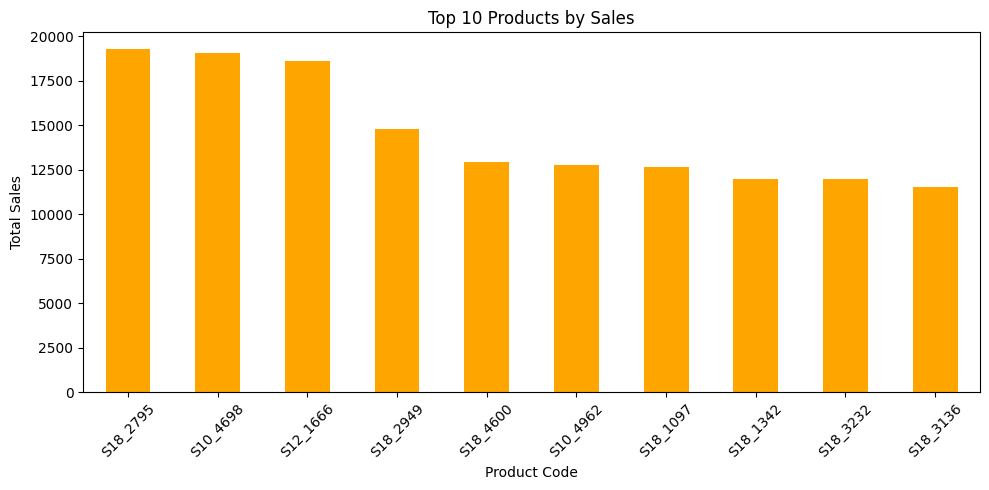

In [16]:
# top 10 products by sales
top_products = df.groupby('PRODUCTCODE')['SALES'].sum().nlargest(10)

plt.figure(figsize=(10, 5))
top_products.plot(kind='bar', color='orange')
plt.title('Top 10 Products by Sales')
plt.xlabel('Product Code')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

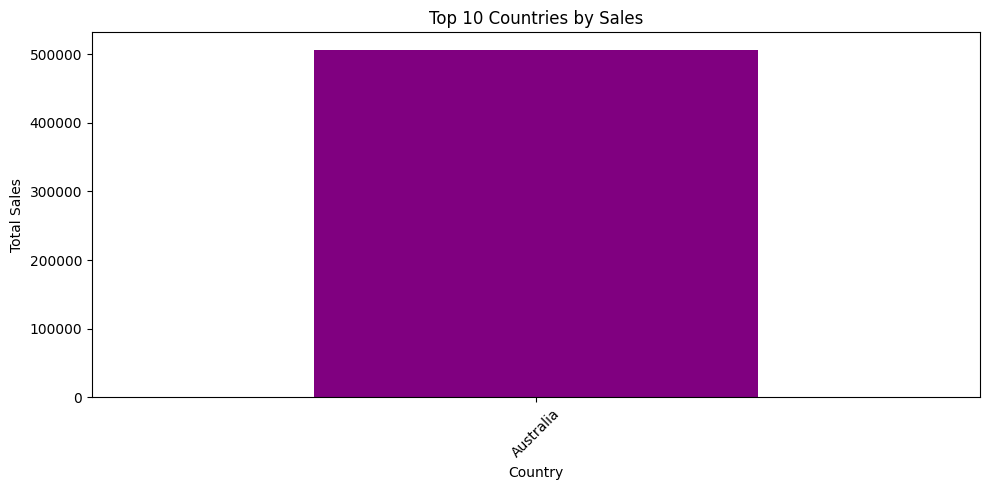

In [17]:
# top 10 countries by sales
top_countries = df.groupby('COUNTRY')['SALES'].sum().nlargest(10)

plt.figure(figsize=(10, 5))
top_countries.plot(kind='bar', color='purple')
plt.title('Top 10 Countries by Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

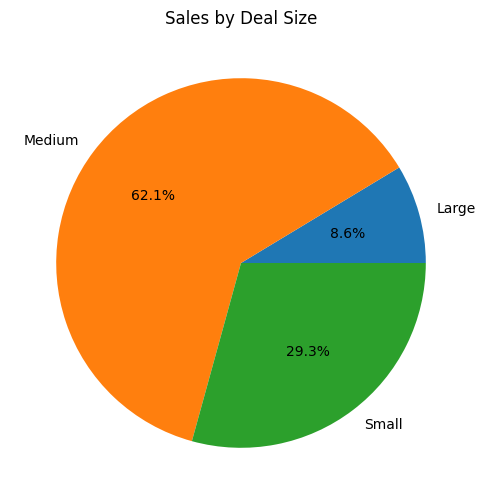

In [18]:
# deal size distribution
deal_sales = df.groupby('DEALSIZE')['SALES'].sum()

plt.figure(figsize=(6, 6))
deal_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales by Deal Size')
plt.ylabel('')
plt.show()

In [19]:
print('Top Performing Category:', df.groupby('PRODUCTLINE')['SALES'].sum().idxmax())
print('Top Performing Country:', df.groupby('COUNTRY')['SALES'].sum().idxmax())
print('Top Performing Product:', df.groupby('PRODUCTCODE')['SALES'].sum().idxmax())
print('Best Deal Size:', df.groupby('DEALSIZE')['SALES'].sum().idxmax())

Top Performing Category: Classic Cars
Top Performing Country: Australia
Top Performing Product: S18_2795
Best Deal Size: Medium


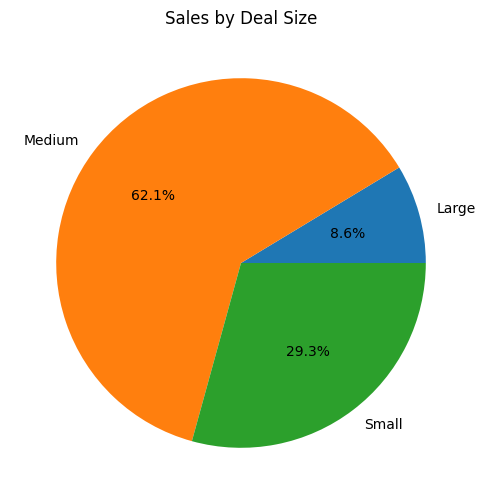

In [20]:
# deal size distribution
deal_sales = df.groupby('DEALSIZE')['SALES'].sum()

plt.figure(figsize=(6, 6))
deal_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales by Deal Size')
plt.ylabel('')
plt.show()

## Summary

In this project I analyzed a sales dataset using Python and Pandas.

- Loaded and cleaned the CSV data
- Calculated basic statistics like total, average, max and min sales
- Created bar charts and pie charts for category and country wise sales
- Found the top performing products and regions
- Classic Cars had the highest sales among all categories
- USA was the top country by revenue